# Feature Importance and Model Interpretability

After building and evaluating regression models, it is important to understand how individual features contribute to the model's predictions.

While performance metrics such as R-squared and RMSE tell us how well the model performs, they do not explain *why* the model makes certain predictions.

Feature importance analysis helps answer key questions:

- Which variables have the strongest influence on bike-sharing demand?
- Which features increase or decrease demand?
- Do the results align with real-world expectations?

In linear regression models, feature importance is determined by the magnitude and direction of coefficients:

- Larger absolute coefficients indicate stronger influence
- Positive coefficients indicate a direct relationship
- Negative coefficients indicate an inverse relationship

This notebook focuses on extracting, analyzing, and visualizing feature importance to improve model interpretability and support decision-making.

## Import Required Libraries

We import the necessary libraries for:

- Data manipulation and processing
- Model training
- Visualization of feature importance

These tools allow us to interpret the model effectively.

In [1]:
# Import pandas for handling structured data
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical plots
import seaborn as sns


# Import LinearRegression model for extracting coefficients
from sklearn.linear_model import LinearRegression

# Set visualization style for consistency
sns.set(style="whitegrid")

## Load and Prepare Dataset

We load the normalized dataset produced by notebook 02, lowercase its column names for robustness, and convert `functioning_day` (`Yes`/`No`) into a 0/1 integer so that all features are numeric. The model below is fit on the full dataset (this notebook focuses on coefficient interpretation, not held-out evaluation), so no train/test split is required here.

In [ ]:
# ── Load and Prepare Dataset ──────────────────────────────────
df = pd.read_csv("seoul_bike_sharing_converted_normalized.csv")                 # load normalized dataset produced by notebook 02
df.columns = df.columns.str.lower()                                             # lowercase column names for robustness
df['functioning_day'] = (df['functioning_day'].str.lower() == 'yes').astype(int)  # encode Yes/No as 1/0 so it is numeric for the regression


## Define Features and Target

We separate the dataset into a feature matrix `X` and target vector `y`. We drop the raw `date` column from `X` because its temporal signal is already encoded in `year`, `month`, and `day_of_week`, and `LinearRegression` cannot consume `datetime`/string columns directly.

In [ ]:
# ── Define Features and Target ────────────────────────────────
X = df.drop(columns=['rented_bike_count', 'date'])    # drop target and raw date (date already encoded in year/month/day_of_week)
y = df['rented_bike_count']                           # target: hourly bike rentals (normalized)


## Train Linear Regression Model

We train a linear regression model using the full dataset.

The purpose of this model is not prediction, but interpretation — specifically, extracting coefficients to understand feature importance.

In [4]:
# Initialize linear regression model
model = LinearRegression()

# Fit the model using all available data
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Extract Feature Importance

The coefficients of the trained model represent the influence of each feature.

We create a structured DataFrame to:

- Store feature names
- Store corresponding coefficients
- Calculate absolute values for ranking importance

In [5]:
# Create DataFrame to store feature importance

feature_importance = pd.DataFrame({
    
    # Store feature names from dataset
    'Feature': X.columns,
    
    # Store corresponding coefficients from model
    'Coefficient': model.coef_
})

# Calculate absolute value of coefficients for ranking
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()

# Sort features by importance (highest first)
feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient', ascending=False
)

# Display top features
feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
7,rainfall,-0.568011,0.568011
2,humidity,-0.342683,0.342683
5,dew_point_temperature,0.287692,0.287692
0,hour,0.178963,0.178963
1,temperature,0.155334,0.155334
12,seasons_winter,-0.104398,0.104398
8,snowfall,0.083264,0.083264
6,solar_radiation,-0.072783,0.072783
9,functioning_day,0.057274,0.057274
11,seasons_summer,-0.042811,0.042811


## Visualize Feature Importance (Magnitude)

We visualize the top features based on the magnitude of their coefficients.

This helps identify which variables have the strongest influence on predictions, regardless of direction.

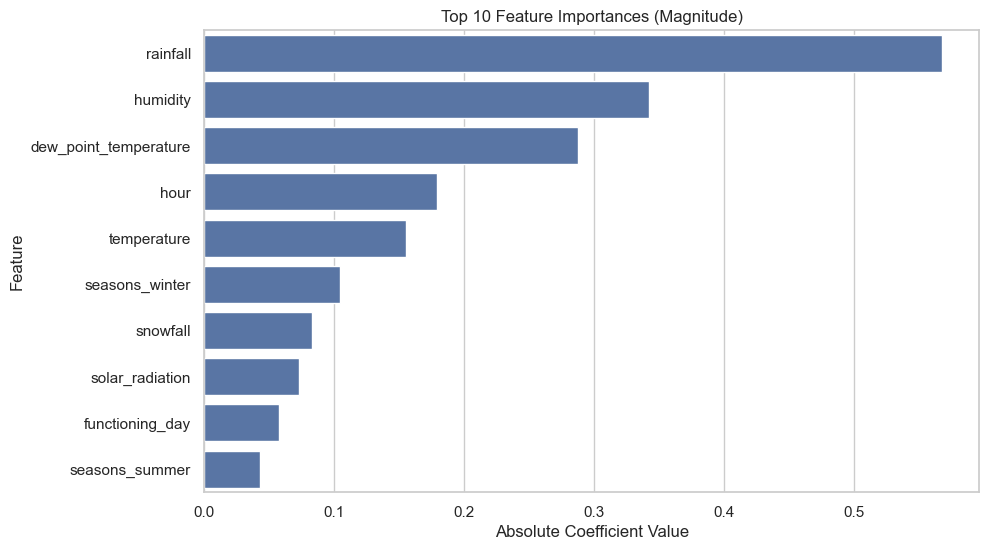

In [6]:
# Select top 10 most important features
top_features = feature_importance.head(10)

# Create figure for visualization
plt.figure(figsize=(10,6))

# Create horizontal bar plot
sns.barplot(
    data=top_features,
    x='Abs_Coefficient',
    y='Feature'
)

# Add title and labels
plt.title("Top 10 Feature Importances (Magnitude)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

# Display plot
plt.show()

## Visualize Feature Influence (Direction)

In addition to magnitude, it is important to understand the direction of influence:

- Positive coefficients increase bike demand
- Negative coefficients decrease bike demand

We visualize both magnitude and direction using signed coefficients.

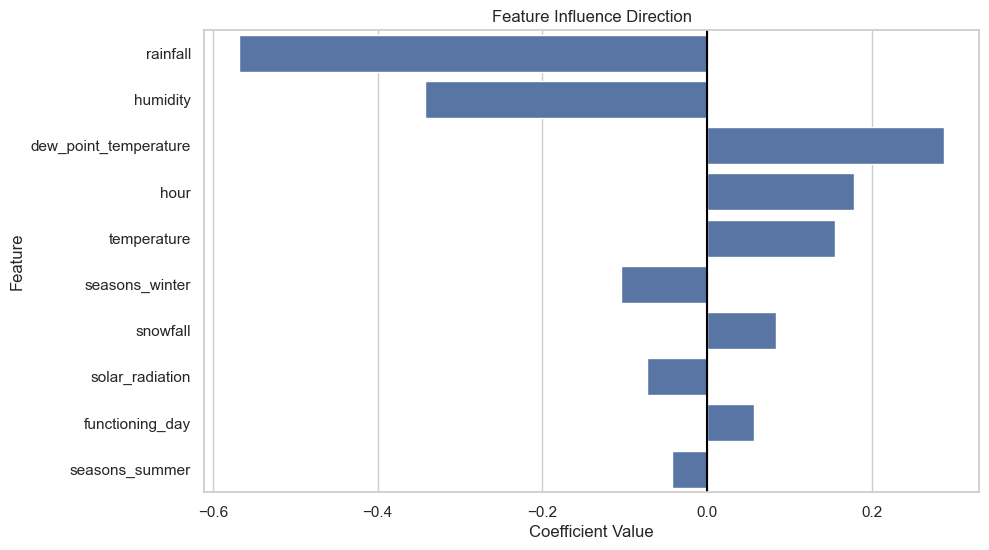

In [7]:
# Create figure
plt.figure(figsize=(10,6))

# Plot feature coefficients (including sign)
sns.barplot(
    data=feature_importance.head(10),
    x='Coefficient',
    y='Feature'
)

# Add vertical line at zero to separate positive and negative effects
plt.axvline(0, color='black')

# Add labels and title
plt.title("Feature Influence Direction")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

# Display plot
plt.show()

## Interpretation

From the feature importance analysis:

- Features with large positive coefficients significantly increase bike demand
- Features with large negative coefficients reduce demand
- Weather variables such as temperature often show strong positive relationships
- Humidity and adverse conditions may negatively affect demand
- Time-related variables typically capture behavioral patterns such as commuting hours

This analysis provides valuable insight into how different factors influence bike-sharing usage and supports both model interpretation and business decision-making.

---

## Author & Acknowledgment

**Author:**  
Deepan Mehta  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on interpreting regression models by analyzing feature importance through model coefficients and visualization techniques.

The approach is inspired by foundational regression concepts and IBM Skills Network instructional materials on model interpretation.

Special acknowledgment is given to:

- Yan Luo  
- Jeff Grossman  
- Rav Ahuja et al. at the IBM Skills Network  

---

## Project Context

This notebook represents the model interpretability stage within the broader pipeline:

- Data Collection  
- Data Wrangling  
- EDA  
- Model Development  
- Model Evaluation  
- Model Interpretation  

---

## Notes

All code and explanations have been independently structured to emphasize clarity, interpretability, and practical understanding of feature importance in predictive modeling.

---